<a href="https://colab.research.google.com/github/pradervonsky/vbig-lab/blob/main/evaluation/eval_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Small VLMs Evaluation Pipeline with G-Eval

## Initial steps

In [19]:
!pip install --q supabase sweetviz

In [20]:
import re
import math
import numpy as np
import pandas as pd
from google.colab import userdata, drive
from supabase import create_client

In [21]:
SUPABASE_URL = userdata.get("SUPABASE_URL")
SUPABASE_KEY = userdata.get("SUPABASE_KEY")

supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

In [22]:
# Load Supabase for analysis
all_rows  = []
page_size = 1000
offset    = 0

while True:
    resp = supabase.table("eval_scores").select(
        "model_name, metadata_id, dashboard_name, chart_id, chart_title, level, "
        "generated, reference, generation_success, degenerate_pattern, "
        "rouge1, rouge2, rougel, bertscore_f1, "
        "geval, geval_reason"
    ).range(offset, offset + page_size - 1).execute()
    batch = resp.data
    if not batch:
        break
    all_rows.extend(batch)
    if len(batch) < page_size:
        break
    offset += page_size

df_qual = pd.DataFrame(all_rows)
df_qual = df_qual.rename(columns={"rougel": "rougeL"})
df_qual = df_qual[df_qual["model_name"] != "SmolVLM-256M-Instruct"].copy()

print(f"df_qual shape : {df_qual.shape}")
print(f"Models        : {sorted(df_qual['model_name'].unique())}")
print(f"Columns       : {df_qual.columns.tolist()}")

df_qual shape : (6297, 16)
Models        : ['InternVL2-1B', 'InternVL2-2B', 'InternVL3-1B-hf', 'Qwen3-VL-2B-Instruct', 'Qwen3.5-0.8B', 'Qwen3.5-2B', 'moondream2']
Columns       : ['model_name', 'metadata_id', 'dashboard_name', 'chart_id', 'chart_title', 'level', 'generated', 'reference', 'generation_success', 'degenerate_pattern', 'rouge1', 'rouge2', 'rougeL', 'bertscore_f1', 'geval', 'geval_reason']


                                             |          | [  0%]   00:00 -> (? left)


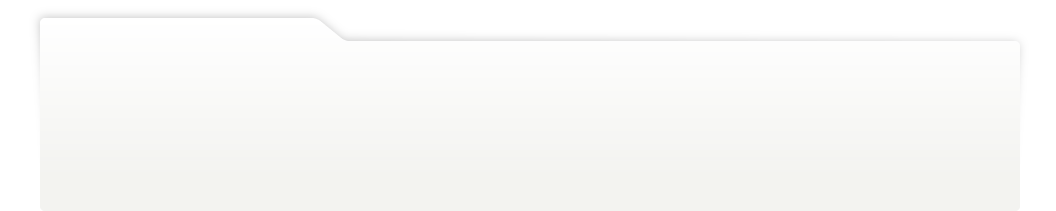
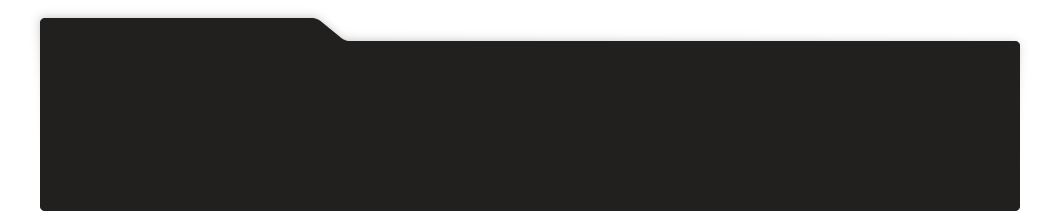
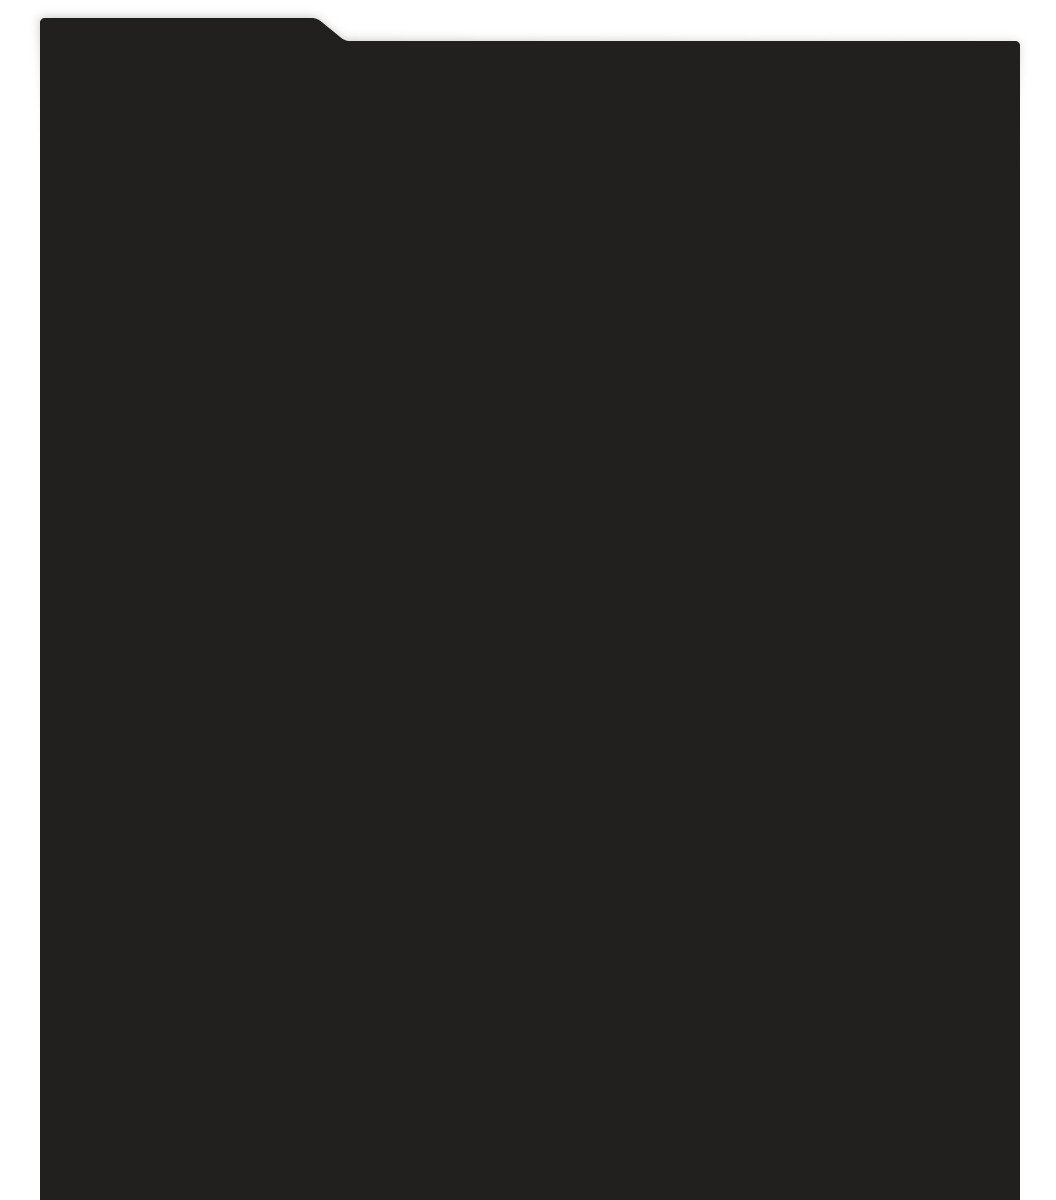
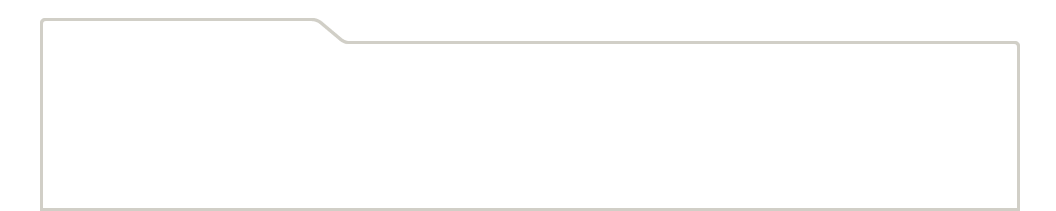
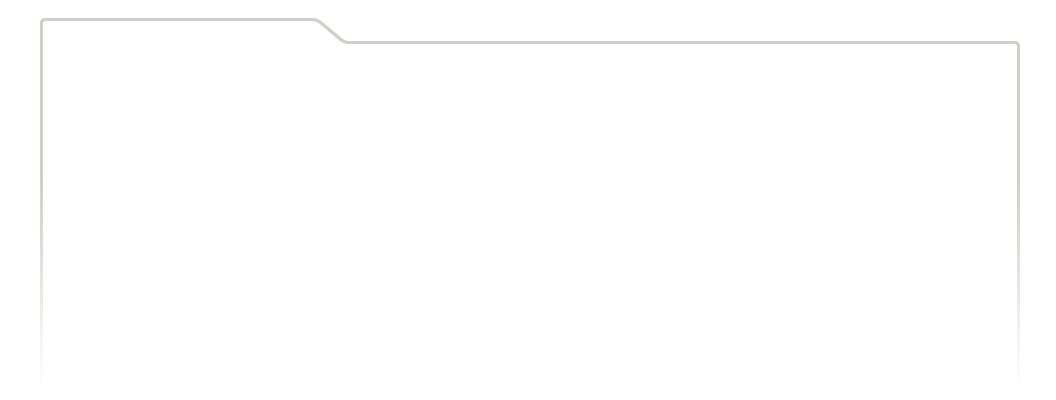
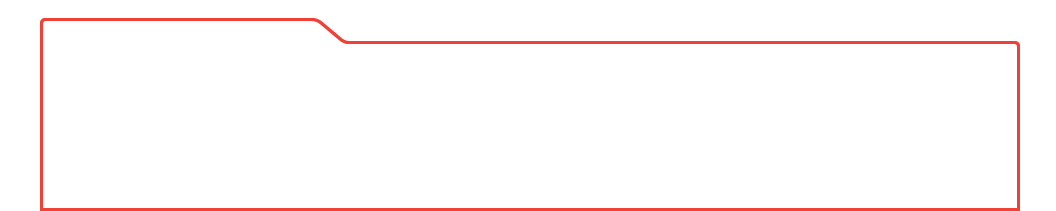
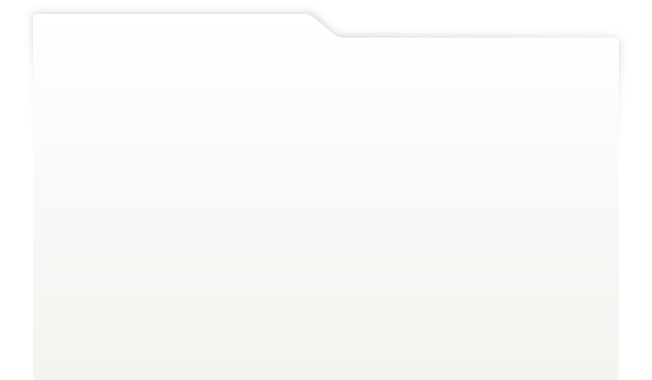
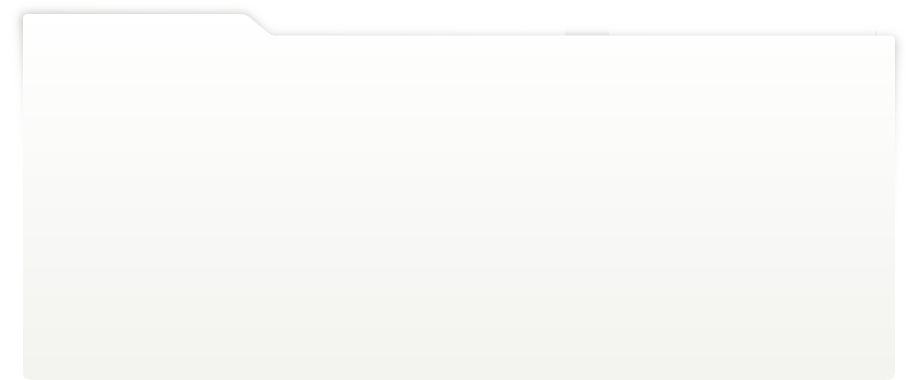
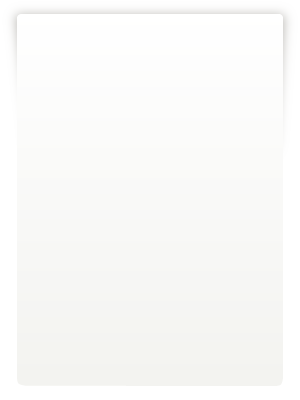
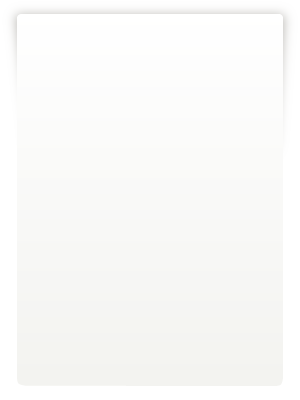
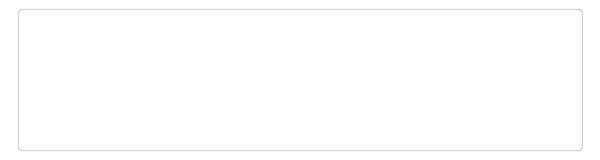
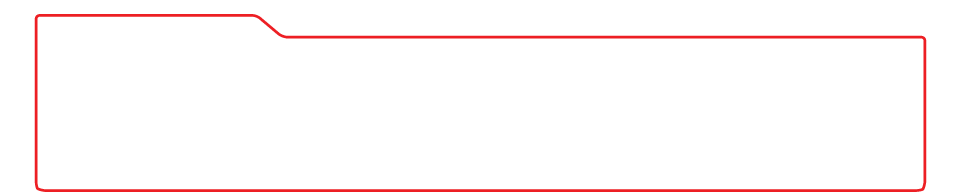
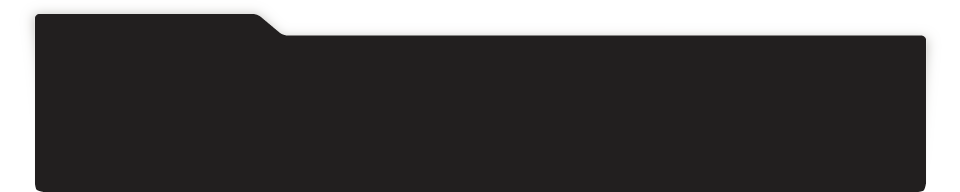
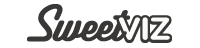
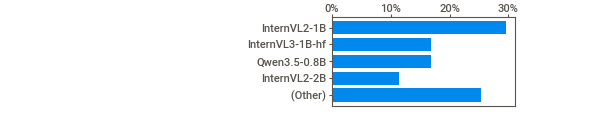
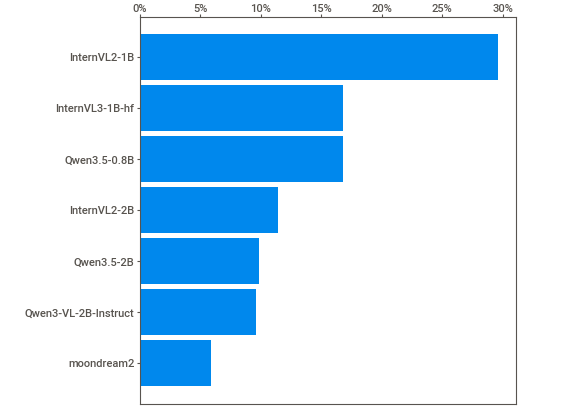
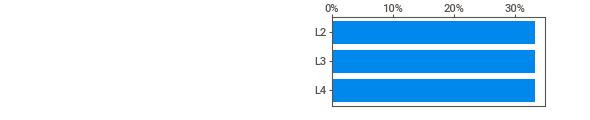
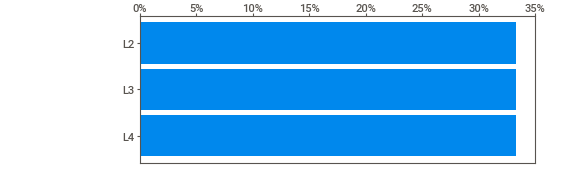
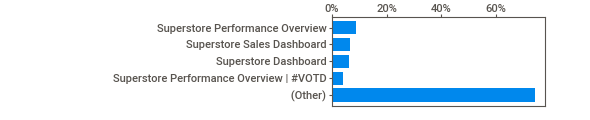
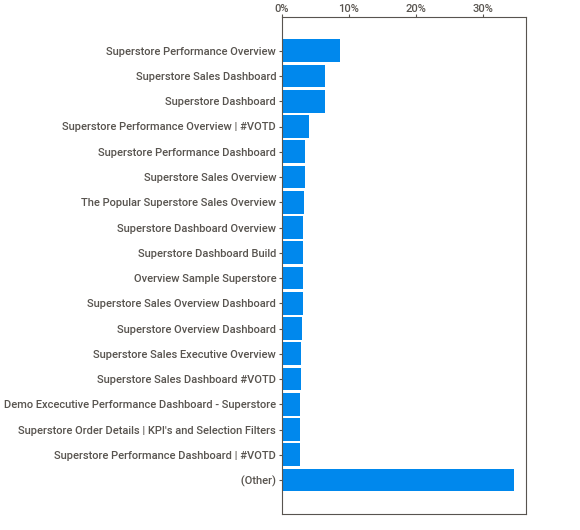
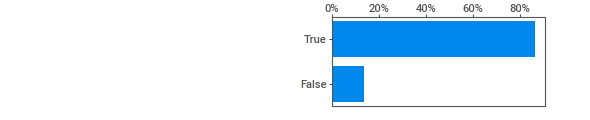
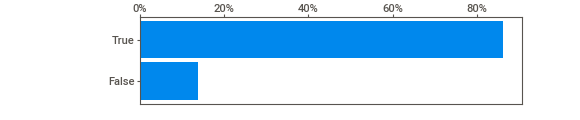
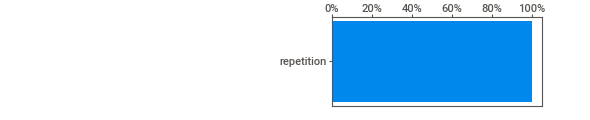
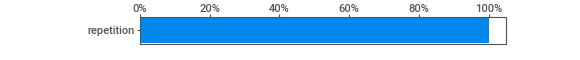
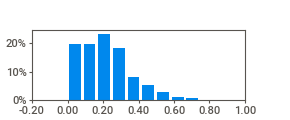
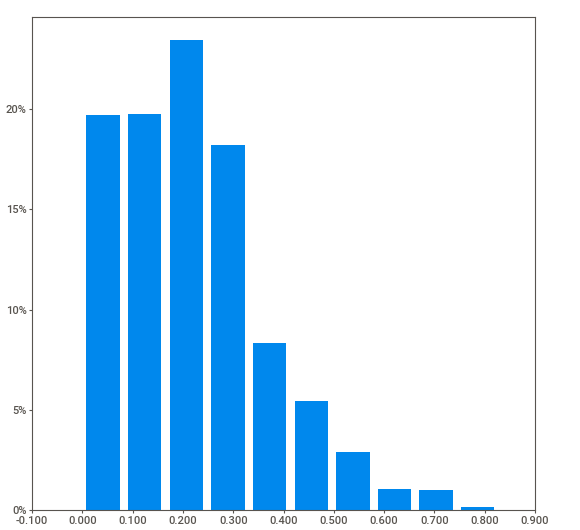
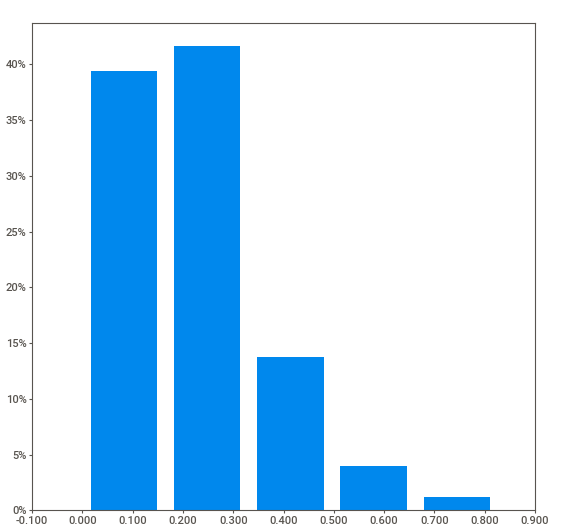
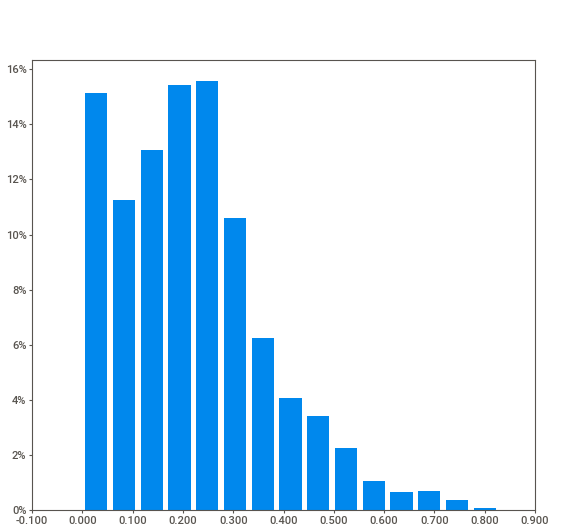
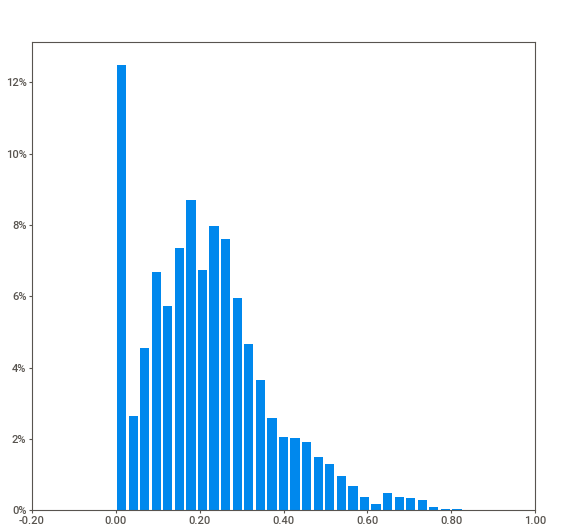
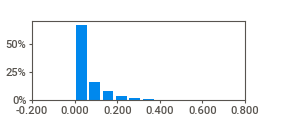
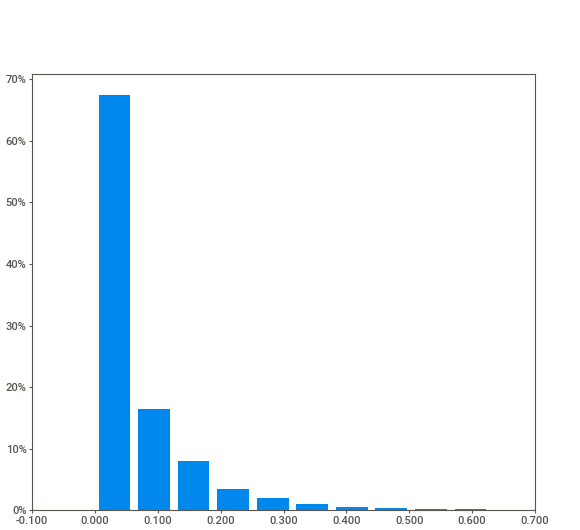
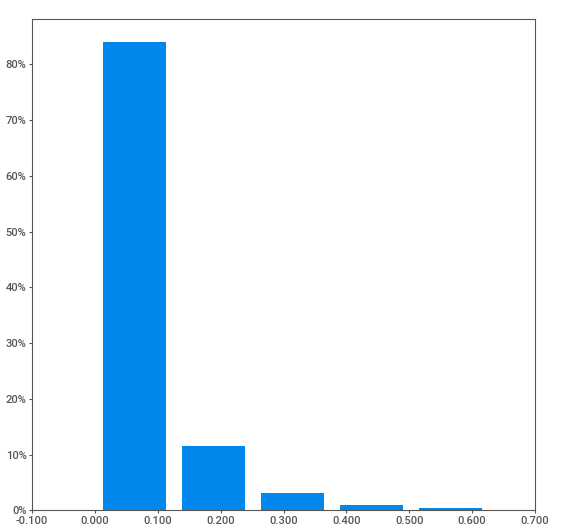
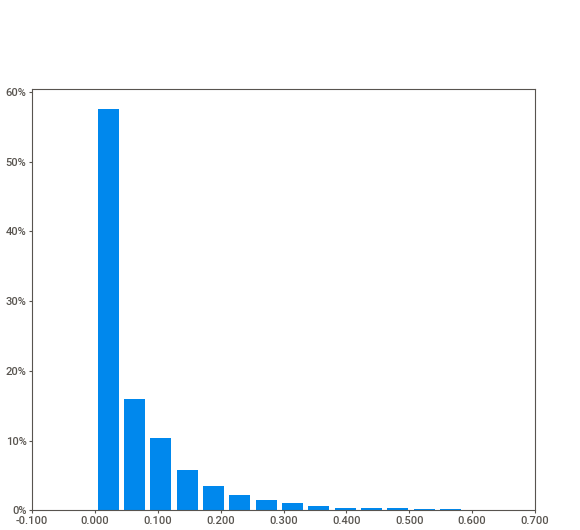
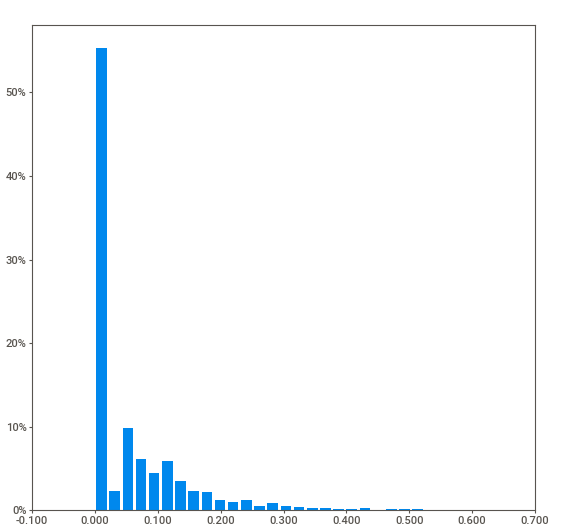
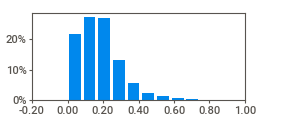
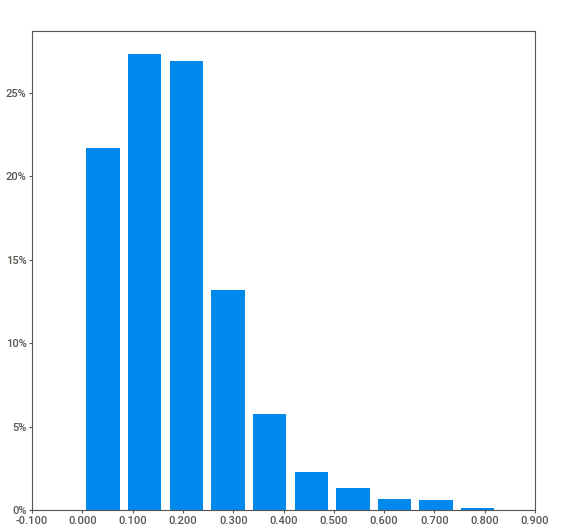
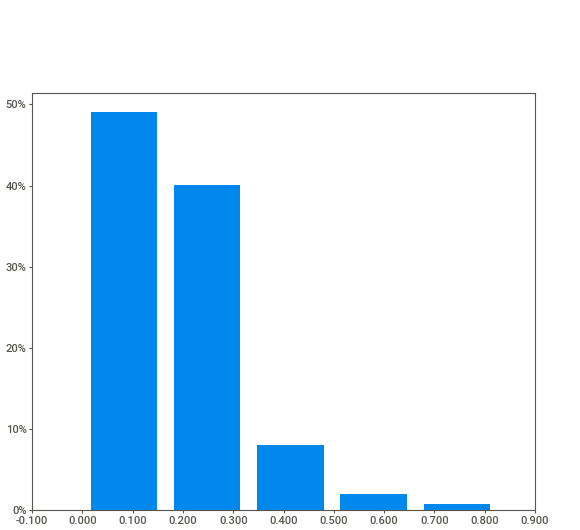
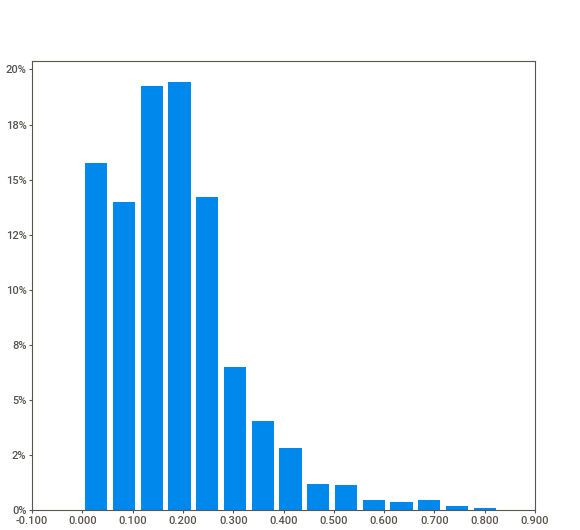
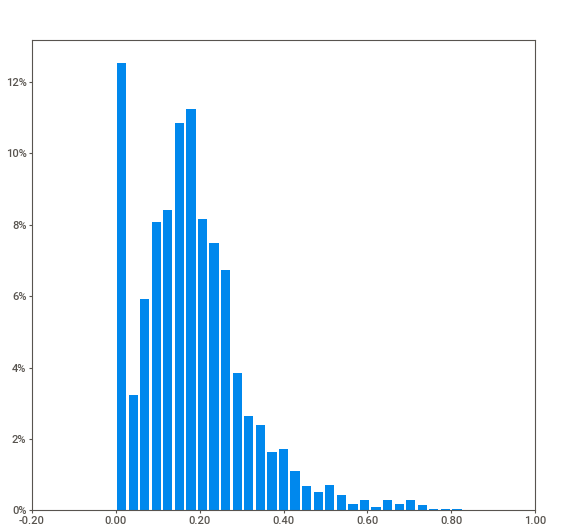
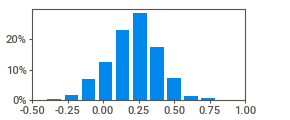
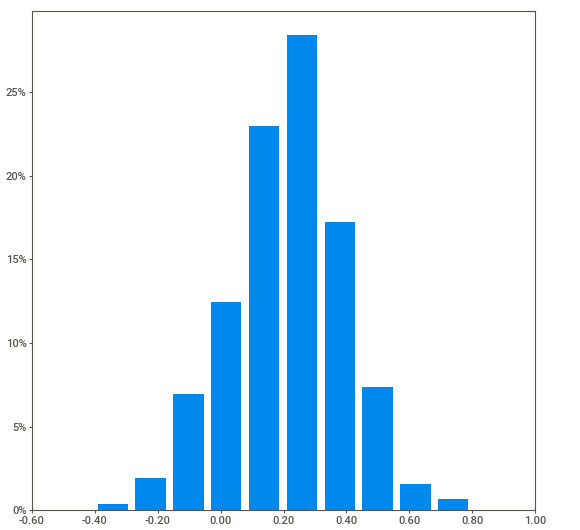
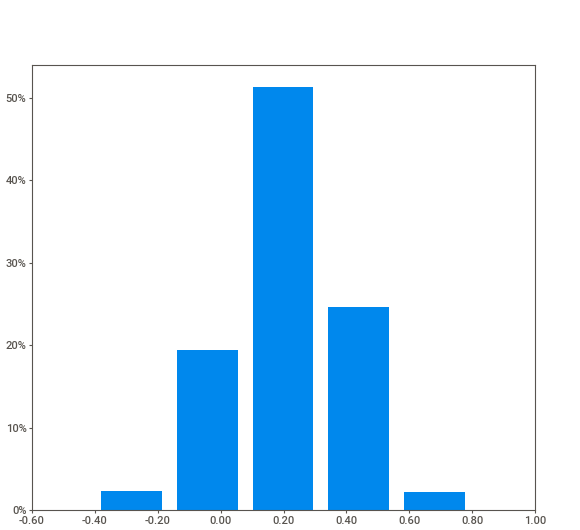
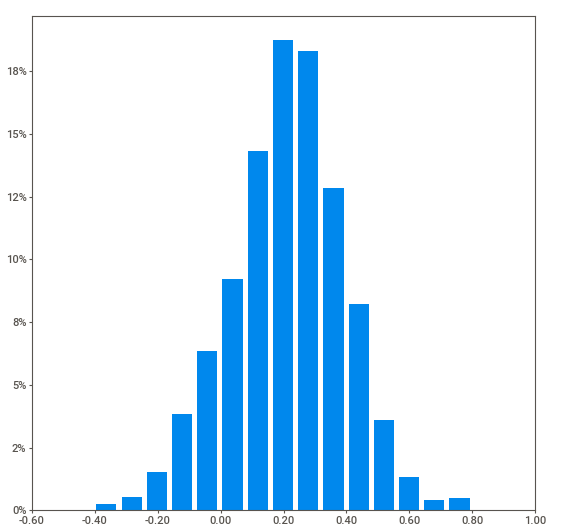
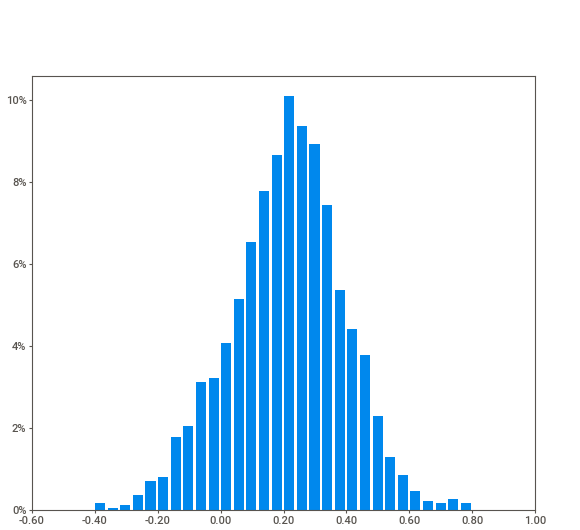
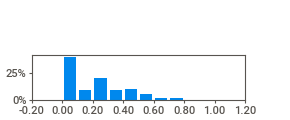
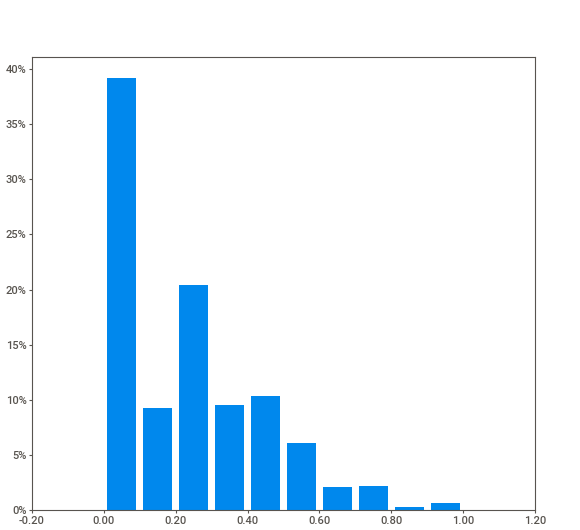
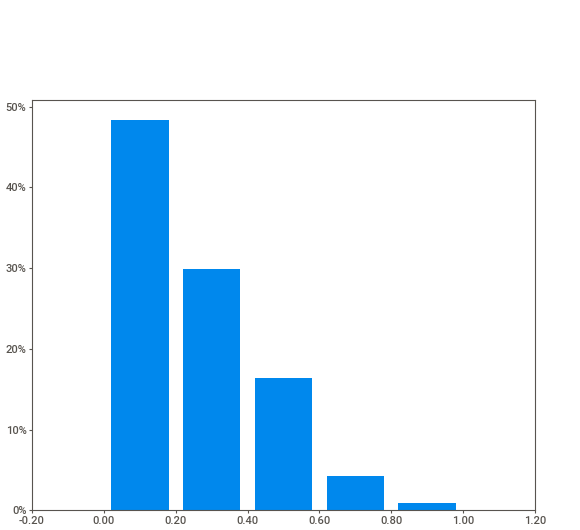
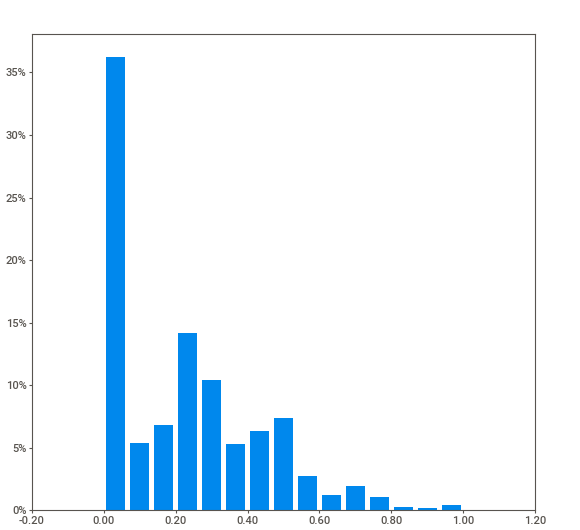
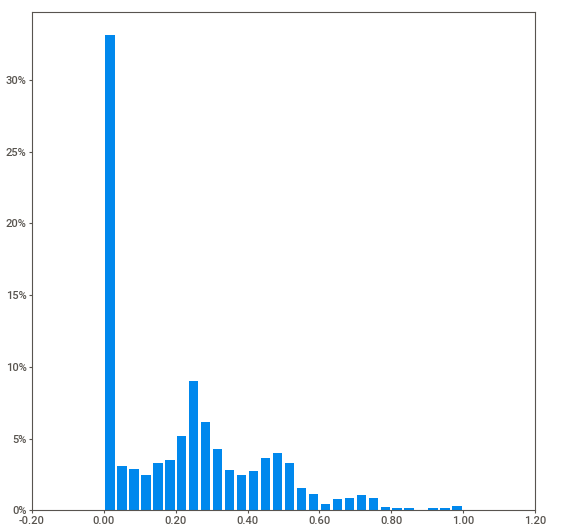
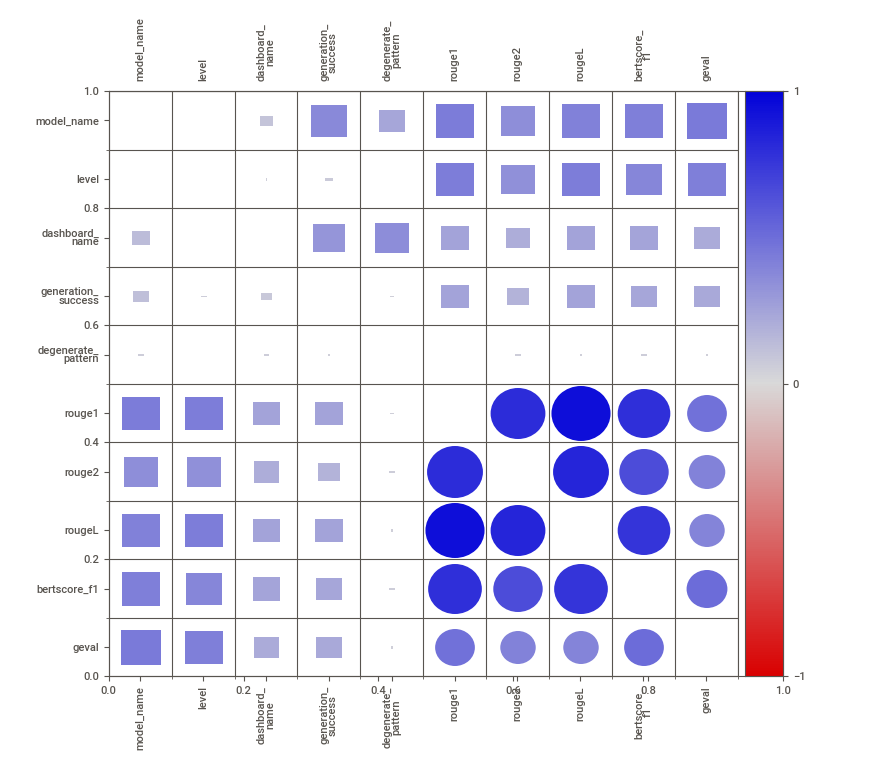
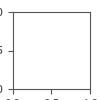

In [23]:
import sweetviz as sv

# Only numeric + key categorical columns for cleaner report
cols_for_eda = [
    "model_name", "level", "dashboard_name",
    "generation_success", "degenerate_pattern",
    "rouge1", "rouge2", "rougeL", "bertscore_f1", "geval"
]

report = sv.analyze(df_qual[cols_for_eda])
report.show_notebook()

## Evaluation results

### Performance across semantic levels

In [24]:
def level_summary(df, metric_col, levels):
    sub = df[df["level"].isin(levels) & df[metric_col].notna()]
    return sub.groupby("level")[metric_col].agg(
        mean="mean", sd="std"
    ).round(4)

def fmt_mean_sd(df_summary, label):
    col = df_summary.apply(
        lambda r: f"{r['mean']:.3f} ± {r['sd']:.3f}" if pd.notna(r['mean']) else "-",
        axis=1
    ).rename(label)
    return col

rouge1_summary = level_summary(df_qual, "rouge1",       ["L2","L3"])
rouge2_summary = level_summary(df_qual, "rouge2",       ["L2","L3"])
rougeL_summary = level_summary(df_qual, "rougeL",       ["L2","L3"])
bert_summary   = level_summary(df_qual, "bertscore_f1", ["L2","L3"])
geval_summary  = level_summary(df_qual, "geval",        ["L3","L4"])

table_43 = pd.concat([
    fmt_mean_sd(rouge1_summary, "ROUGE-1"),
    fmt_mean_sd(rouge2_summary, "ROUGE-2"),
    fmt_mean_sd(rougeL_summary, "ROUGE-L"),
    fmt_mean_sd(bert_summary,   "BERTScore"),
    fmt_mean_sd(geval_summary,  "G-Eval"),
], axis=1).reindex(["L2","L3","L4"]).fillna("-")

print("=== Performance Across Semantic Levels (mean ± SD) ===")
print(table_43.to_string())

=== Performance Across Semantic Levels (mean ± SD) ===
             ROUGE-1        ROUGE-2        ROUGE-L      BERTScore         G-Eval
level                                                                           
L2     0.228 ± 0.176  0.078 ± 0.107  0.195 ± 0.154  0.213 ± 0.206              -
L3     0.198 ± 0.113  0.032 ± 0.057  0.160 ± 0.089  0.208 ± 0.141  0.143 ± 0.223
L4                 -              -              -              -  0.290 ± 0.179


### Performance across models


In [25]:
# across dashboard-chart

def ms(df_model, level, metric):
    sub = df_model[(df_model["level"] == level) & df_model[metric].notna()][metric]
    return sub.mean(), sub.std()

def fmt(mean, sd):
    if pd.isna(mean):
        return "-"
    return f"{mean:.3f} ± {sd:.3f}"

# Compute composite score per model: mean of BERTScore@L2, BERTScore@L3, G-Eval@L4
composite_scores = {}
for model in df_qual["model_name"].unique():
    m = df_qual[df_qual["model_name"] == model]
    bs_l2 = ms(m, "L2", "bertscore_f1")[0]
    bs_l3 = ms(m, "L3", "bertscore_f1")[0]
    ge_l4 = ms(m, "L4", "geval")[0]
    scores = [s for s in [bs_l2, bs_l3, ge_l4] if pd.notna(s)]
    composite_scores[model] = sum(scores) / len(scores) if scores else 0

# Sort models by composite score descending
models_ranked = sorted(composite_scores, key=composite_scores.get, reverse=True)

print("=== Model Composite Scores (for ranking) ===")
for m, s in sorted(composite_scores.items(), key=lambda x: -x[1]):
    print(f"  {m:30s}  {s:.4f}")

# Build table in ranked order
rows = []
for model in models_ranked:
    m = df_qual[df_qual["model_name"] == model]
    for level in ["L2", "L3", "L4"]:
        row = {
            "Model"    : model if level == "L2" else "",
            "Level"    : level,
            "ROUGE-1"  : fmt(*ms(m, level, "rouge1"))       if level in ["L2","L3"] else "-",
            "ROUGE-2"  : fmt(*ms(m, level, "rouge2"))       if level in ["L2","L3"] else "-",
            "ROUGE-L"  : fmt(*ms(m, level, "rougeL"))       if level in ["L2","L3"] else "-",
            "BERTScore": fmt(*ms(m, level, "bertscore_f1")) if level in ["L2","L3"] else "-",
            "G-Eval"   : fmt(*ms(m, level, "geval"))        if level in ["L3","L4"] else "-",
        }
        rows.append(row)

table_44 = pd.DataFrame(rows).set_index(["Model", "Level"])
print("\n=== Model x Metric Performance (mean ± SD), ranked by composite score ===")
print(table_44.to_string())

=== Model Composite Scores (for ranking) ===
  Qwen3.5-2B                      0.3486
  Qwen3-VL-2B-Instruct            0.3300
  InternVL3-1B-hf                 0.2266
  Qwen3.5-0.8B                    0.2215
  InternVL2-2B                    0.2084
  moondream2                      0.1006
  InternVL2-1B                    0.0987

=== Model x Metric Performance (mean ± SD), ranked by composite score ===
                                  ROUGE-1        ROUGE-2        ROUGE-L      BERTScore         G-Eval
Model                Level                                                                           
Qwen3.5-2B           L2     0.366 ± 0.172  0.143 ± 0.127  0.300 ± 0.154  0.347 ± 0.155              -
                     L3     0.256 ± 0.093  0.039 ± 0.049  0.194 ± 0.062  0.274 ± 0.097  0.275 ± 0.276
                     L4                 -              -              -              -  0.425 ± 0.179
Qwen3-VL-2B-Instruct L2     0.325 ± 0.191  0.135 ± 0.131  0.278 ± 0.173  0.315 ± 0.

In [26]:
def ms_dashboard(df_model, level, metric):
    sub = df_model[(df_model["level"] == level) & df_model[metric].notna()]
    if sub.empty:
        return float("nan"), float("nan")
    dash_means = sub.groupby("metadata_id")[metric].mean()
    return dash_means.mean(), dash_means.std()

# Build table dashboard-level SD
rows_b = []
for model in models_ranked:
    m = df_qual[df_qual["model_name"] == model]
    for level in ["L2", "L3", "L4"]:
        row = {
            "Model"    : model if level == "L2" else "",
            "Level"    : level,
            "ROUGE-1"  : fmt(*ms_dashboard(m, level, "rouge1"))       if level in ["L2","L3"] else "-",
            "ROUGE-2"  : fmt(*ms_dashboard(m, level, "rouge2"))        if level in ["L2","L3"] else "-",
            "ROUGE-L"  : fmt(*ms_dashboard(m, level, "rougeL"))        if level in ["L2","L3"] else "-",
            "BERTScore": fmt(*ms_dashboard(m, level, "bertscore_f1"))  if level in ["L2","L3"] else "-",
            "G-Eval"   : fmt(*ms_dashboard(m, level, "geval"))         if level in ["L3","L4"] else "-",
        }
        rows_b.append(row)

table_44b = pd.DataFrame(rows_b).set_index(["Model", "Level"])
print("\n=== Dashboard-Level SD ===")
print(table_44b.to_string())


=== Dashboard-Level SD ===
                                  ROUGE-1        ROUGE-2        ROUGE-L      BERTScore         G-Eval
Model                Level                                                                           
Qwen3.5-2B           L2     0.357 ± 0.122  0.144 ± 0.076  0.294 ± 0.097  0.342 ± 0.111              -
                     L3     0.246 ± 0.063  0.035 ± 0.027  0.187 ± 0.039  0.266 ± 0.065  0.266 ± 0.196
                     L4                 -              -              -              -  0.410 ± 0.124
Qwen3-VL-2B-Instruct L2     0.333 ± 0.131  0.135 ± 0.086  0.283 ± 0.107  0.323 ± 0.144              -
                     L3     0.255 ± 0.076  0.067 ± 0.063  0.197 ± 0.064  0.291 ± 0.105  0.296 ± 0.192
                     L4                 -              -              -              -  0.404 ± 0.132
InternVL3-1B-hf      L2     0.230 ± 0.076  0.070 ± 0.048  0.197 ± 0.068  0.216 ± 0.123              -
                     L3     0.201 ± 0.073  0.027 ± 0.0

### Performance within family

In [27]:
FAMILY_PAIRS = {
    "Qwen3.5"  : ("Qwen3.5-0.8B", "Qwen3.5-2B"),
    "InternVL2": ("InternVL2-1B",  "InternVL2-2B"),
}

METRICS_PER_LEVEL = {
    "rouge1"      : ["L2", "L3"],
    "bertscore_f1": ["L2", "L3"],
    "geval"       : ["L3", "L4"],
}

scaling_rows = []
for family, (small, large) in FAMILY_PAIRS.items():
    first_row = True
    for metric, levels in METRICS_PER_LEVEL.items():
        first_metric = True
        for level in levels:
            sub        = df_qual[df_qual["level"] == level]
            small_mean = sub[sub["model_name"] == small][metric].mean()
            large_mean = sub[sub["model_name"] == large][metric].mean()
            delta      = round(large_mean - small_mean, 4) if not (
                pd.isna(small_mean) or pd.isna(large_mean)
            ) else None

            scaling_rows.append({
                "Family": family if first_row else "",
                "Metric": metric if first_metric else "",
                "Level" : level,
                "Small" : round(small_mean, 4) if not pd.isna(small_mean) else "-",
                "Large" : round(large_mean, 4) if not pd.isna(large_mean) else "-",
                "Delta" : delta if delta is not None else "-",
            })
            first_row    = False
            first_metric = False

df_scaling = pd.DataFrame(scaling_rows)
print("\n=== Within-Family Parameter Scaling ===")
print(df_scaling.to_string(index=False))


=== Within-Family Parameter Scaling ===
   Family       Metric Level  Small  Large  Delta
  Qwen3.5       rouge1    L2 0.1393 0.3659 0.2266
                          L3 0.2231 0.2555 0.0324
          bertscore_f1    L2 0.1588 0.3471 0.1884
                          L3 0.2316 0.2741 0.0425
                 geval    L3 0.1022 0.2750 0.1728
                          L4 0.2742 0.4245 0.1504
InternVL2       rouge1    L2 0.1313 0.2053 0.0739
                          L3 0.0825 0.1613 0.0788
          bertscore_f1    L2 0.1133 0.1930 0.0797
                          L3 0.0649 0.1906 0.1257
                 geval    L3 0.0511 0.0749 0.0238
                          L4 0.1179 0.2417 0.1239


## Qualitative analysis

In [28]:
# Load the human_insights to extract the true GT keys numbers and original chart title

# human_insights: primary annotator ground truth (insight_part_1)
human_resp = supabase.table("human_insights").select("*").execute()
df_human_raw = pd.DataFrame(human_resp.data)

# metadata: dashboard_name lookup
meta_resp = supabase.table("metadata").select("id, dashboard_name, dashboard_author").execute()
df_meta = pd.DataFrame(meta_resp.data).rename(columns={"id": "metadata_id"})

# Keep only rows that are in the final eval corpus:
# expected_dataset=True AND rejection_reason IS NULL
df_human = df_human_raw[
    (df_human_raw["expected_dataset"] == True) &
    (df_human_raw["rejection_reason"].isna())
].copy()

# Attach dashboard_name
df_human = df_human.merge(df_meta, on="metadata_id", how="left")

print(f"Eval dashboards (human_insights): {len(df_human)}")
assert len(df_human) == 40, f"Expected 40, got {len(df_human)}"

Eval dashboards (human_insights): 40


In [29]:
NA_PATTERN = re.compile(r"^(not applicable|n/a)$", re.IGNORECASE)

def normalize_value(val):
    if val is None:
        return None
    cleaned = str(val).strip().rstrip(".").strip()
    if cleaned == "" or NA_PATTERN.match(cleaned):
        return None
    return cleaned

def parse_charts(text):
    charts = []
    if not text or (isinstance(text, float) and np.isnan(text)):
        return charts

    # Split on any Chart/Chat header; keep delimiter via lookahead
    blocks = re.split(r"(?=(?:Chart|Chat)\s+\d+\s*[:.])", str(text).strip())

    for block in blocks:
        block = block.strip()
        if not block:
            continue
        lines = block.splitlines()
        header = lines[0].strip()
        match = re.match(r"(?:Chart|Chat)\s+(\d+)\s*[:.]\s*(.*)", header)
        if not match:
            continue
        chart_id = int(match.group(1))
        title    = match.group(2).strip()

        L2 = L3 = L4 = None
        for line in lines[1:]:
            line = line.strip()
            if line.startswith("L2:"):
                L2 = normalize_value(line[3:].strip())
            elif line.startswith("L3:"):
                L3 = normalize_value(line[3:].strip())
            elif line.startswith("L4:"):
                L4 = normalize_value(line[3:].strip())

        charts.append({"chart_id": chart_id, "title": title, "L2": L2, "L3": L3, "L4": L4})
    return charts

In [30]:
# One row per (dashboard × chart × level)
# Reference text = insight_part_1 (primary annotator)

gt_records = []
for _, row in df_human.iterrows():
    metadata_id    = row["metadata_id"]
    dashboard_name = row["dashboard_name"]
    human_id       = row["id"]

    parsed = parse_charts(row["insight_part_1"])

    for chart in parsed:
        for level in ["L2", "L3", "L4"]:
            gt_records.append({
                "human_id"      : human_id,
                "metadata_id"   : metadata_id,
                "dashboard_name": dashboard_name,
                "chart_id"      : chart["chart_id"],
                "chart_title"   : chart["title"],
                "level"         : level,
                "reference"     : chart[level],   # None if NA/empty
            })

df_gt = pd.DataFrame(gt_records)
print(f"Ground truth units : {len(df_gt)}")
print(df_gt.head(9).to_string())

Ground truth units : 612
                               human_id                           metadata_id               dashboard_name  chart_id          chart_title level                                                                                                                                                                                               reference
0  c1c00ab2-139a-4712-9fea-8e87f6d7e70c  ba445ab0-8ff3-45ad-8cb5-ec7275baab13  Superstore - Bento Box KPIs         1  Scoreboard Overview    L2            Corporate sales are $248,244.1, consumer sales are $334,911.9, and home office sales are $162,411.5, cumulating to $745,568 total sales with profit of $95,926 and the profit ratio of 12.9%
1  c1c00ab2-139a-4712-9fea-8e87f6d7e70c  ba445ab0-8ff3-45ad-8cb5-ec7275baab13  Superstore - Bento Box KPIs         1  Scoreboard Overview    L3                                                                                                                                                

In [31]:
gt_scoreboard_ids = set(
    df_gt[
        (df_gt["chart_id"] == 1) &
        (df_gt["chart_title"].str.strip().str.lower() == "scoreboard overview")
    ]["metadata_id"]
)

print(f"Dashboards where GT Chart 1 = 'Scoreboard Overview': {len(gt_scoreboard_ids)} / 40")

Dashboards where GT Chart 1 = 'Scoreboard Overview': 37 / 40


In [32]:
gt_titles = (
    df_gt[["metadata_id", "chart_id", "chart_title"]]
    .drop_duplicates(subset=["metadata_id", "chart_id"])
    .rename(columns={"chart_title": "gt_chart_title"})
)

# Rejoin onto df_qual, replacing the old gt_chart_title
df_qual = df_qual.drop(columns=["gt_chart_title"], errors="ignore").merge(
    gt_titles,
    on=["metadata_id", "chart_id"],
    how="left"
)

print(f"GT chart titles joined: {df_qual['gt_chart_title'].notna().sum()} / {len(df_qual)}")

GT chart titles joined: 3525 / 6297


In [33]:
matched_no_ref = df_qual[
    df_qual['gt_chart_title'].notna() & df_qual['reference'].isna()
]
print(f"Matched chart_id but null reference: {len(matched_no_ref)}")
print(matched_no_ref['level'].value_counts())

Matched chart_id but null reference: 198
level
L3    198
Name: count, dtype: int64


In [34]:
print("=" * 60)
print("DATASET STATISTICS SUMMARY")
print("=" * 60)

# GT baseline
print(f"\n--- Ground Truth ---")
print(f"Total dashboards                : {df_gt['metadata_id'].nunique()}")
print(f"Total unique charts             : {df_gt[['metadata_id','chart_id']].drop_duplicates().shape[0]}")
print(f"Dashboards with Scoreboard OV   : {len(gt_scoreboard_ids)} / {df_gt['metadata_id'].nunique()}")

# df_qual overview
print(f"\n--- df_qual Overview ---")
print(f"Total rows                      : {len(df_qual)}")
print(f"Models                          : {sorted(df_qual['model_name'].unique())}")
print(f"Rows with generated notna       : {df_qual['generated'].notna().sum()}")
print(f"Rows with reference notna       : {df_qual['reference'].notna().sum()}")
print(f"Rows with gt_chart_title notna  : {df_qual['gt_chart_title'].notna().sum()}")
print(f"Rows with both gen+ref notna    : {df_qual[df_qual['generated'].notna() & df_qual['reference'].notna()].shape[0]}")

DATASET STATISTICS SUMMARY

--- Ground Truth ---
Total dashboards                : 40
Total unique charts             : 204
Dashboards with Scoreboard OV   : 37 / 40

--- df_qual Overview ---
Total rows                      : 6297
Models                          : ['InternVL2-1B', 'InternVL2-2B', 'InternVL3-1B-hf', 'Qwen3-VL-2B-Instruct', 'Qwen3.5-0.8B', 'Qwen3.5-2B', 'moondream2']
Rows with generated notna       : 5435
Rows with reference notna       : 3327
Rows with gt_chart_title notna  : 3525
Rows with both gen+ref notna    : 3159


### Easiest-hardest dashboards

In [35]:
# Per dashboard: average score across all models and all levels.
# Composite uses bertscore_f1 and geval.

def row_composite(r):
    level = r.get("level")
    if level == "L2":
        val = r.get("bertscore_f1")
        return val if pd.notna(val) else np.nan
    elif level == "L3":
        val = r.get("bertscore_f1")
        return val if pd.notna(val) else np.nan
    elif level == "L4":
        val = r.get("geval")
        return val if pd.notna(val) else np.nan
    return np.nan

df_qual["composite"] = df_qual.apply(row_composite, axis=1)

dashboard_difficulty = (
    df_qual.groupby(["metadata_id","dashboard_name"])["composite"]
    .mean()
    .reset_index()
    .rename(columns={"composite": "avg_composite_score"})
    .sort_values("avg_composite_score")
)

meta_resp = supabase.table("metadata").select("id, dashboard_author").execute()
df_meta_full = pd.DataFrame(meta_resp.data).rename(columns={"id": "metadata_id"})

dashboard_difficulty = dashboard_difficulty.merge(
    df_meta_full[["metadata_id","dashboard_author"]],
    on="metadata_id",
    how="left"
)

N_HARD = 5
display_cols = ["dashboard_name","dashboard_author","avg_composite_score"]

print(f"=== Hardest Dashboards ===")
print(dashboard_difficulty[display_cols].head(N_HARD).round(4).to_string(index=False))
print(f"\n=== Easiest Dashboards ===")
print(dashboard_difficulty[display_cols].tail(N_HARD).round(4).to_string(index=False))

=== Hardest Dashboards ===
                                        dashboard_name dashboard_author  avg_composite_score
                       Superstore Performance Overview         Julie Li               0.1376
                         Superstore Dashboard Overview        Cathy Lau               0.1381
              Superstore Dashboard - Business Overview    Murilo Cremon               0.1666
Superstore Order Details | KPI's and Selection Filters   Naresh Suglani               0.1737
                             Superstore Sales Overview     Keren Aharon               0.1752

=== Easiest Dashboards ===
                                   dashboard_name dashboard_author  avg_composite_score
                 Superstore Performance Dashboard   Tanya Lomskaya               0.2884
                 Superstore Sales Dashboard #VOTD    Israel Ayoola               0.2920
SuperStore Dashboard - 2019 Sales & Profitability        Linh Pham               0.2968
                                   

### Top scoring samples

In [36]:
TOP_N = 1

# Load author lookup once
meta_resp = supabase.table("metadata").select("id, dashboard_author").execute()
df_meta_full = pd.DataFrame(meta_resp.data).rename(columns={"id": "metadata_id"})

top_examples = []
for model in sorted(df_qual["model_name"].unique()):
    for level in ["L2", "L3", "L4"]:
        if level == "L4":
            metric = "geval"
        elif level == "L2":
            metric = "bertscore_f1"
        else:  # L3
            metric = "bertscore_f1"
        sub = df_qual[
            (df_qual["model_name"] == model) &
            (df_qual["level"]      == level) &
            df_qual[metric].notna()
        ].nlargest(TOP_N, metric)

        for _, r in sub.iterrows():
            top_examples.append({
                "model"            : model,
                "level"            : level,
                "dashboard_name"   : r["dashboard_name"],
                "metadata_id"      : r["metadata_id"],
                "chart"            : r["gt_chart_title"],
                "score"            : round(r[metric], 4),
                "metric_used"      : metric,
                "generated"        : r["generated"],
                "reference"        : r["reference"],
            })

df_top = pd.DataFrame(top_examples).merge(
    df_meta_full[["metadata_id","dashboard_author"]],
    on="metadata_id",
    how="left"
)

print(f"Top examples collected: {len(df_top)}")
print(df_top[["model","level","dashboard_name","dashboard_author","chart","score","metric_used"]].head(21).to_string(index=False))

Top examples collected: 21
               model level                                     dashboard_name       dashboard_author                               chart  score  metric_used
        InternVL2-1B    L2                               Superstore Dashboard          Harshit Gupta                 Profit | By Segment 0.5397 bertscore_f1
        InternVL2-1B    L3  SuperStore Dashboard - 2019 Sales & Profitability              Linh Pham                       Monthly Sales 0.4519 bertscore_f1
        InternVL2-1B    L4                               Superstore Dashboard     Divas Pratap Singh                       Sales By Date 0.6976        geval
        InternVL2-2B    L2                          Superstore Sales Overview           Keren Aharon                 Scoreboard Overview 0.6540 bertscore_f1
        InternVL2-2B    L3 Demo Excecutive Performance Dashboard - Superstore                An Tran                 Scoreboard Overview 0.4696 bertscore_f1
        InternVL2-2B    L4     

### Bottom scoring samples

In [37]:
# Low scoring examples — L3 and L4 only, 1 per model per level
BOTTOM_N = 1

meta_resp = supabase.table("metadata").select("id, dashboard_author").execute()
df_meta_full = pd.DataFrame(meta_resp.data).rename(columns={"id": "metadata_id"})

bottom_examples = []

for model in sorted(df_qual["model_name"].unique()):
    for level in ["L3", "L4"]:
        metric = "geval"

        sub = df_qual[
            (df_qual["model_name"] == model) &
            (df_qual["level"]      == level) &
            df_qual[metric].notna()
        ]

        for _, r in sub.nsmallest(BOTTOM_N, metric).iterrows():
            bottom_examples.append({
                "model"         : model,
                "level"         : level,
                "dashboard_name": r["dashboard_name"],
                "metadata_id"   : r["metadata_id"],
                "chart"         : r["gt_chart_title"],
                "score"         : round(r[metric], 4),
                "generated"     : r["generated"],
                "reference"     : r["reference"],
                "geval_reason"  : r.get("geval_reason", None),
            })

df_bottom = pd.DataFrame(bottom_examples).merge(
    df_meta_full[["metadata_id","dashboard_author"]], on="metadata_id", how="left"
)

print(f"=== Bottom scoring examples per model for L3 and L4 ===")
print(df_bottom[["model","level","dashboard_name","dashboard_author",
                 "chart","generated", "reference","score","geval_reason"]].to_string(index=False))

=== Bottom scoring examples per model for L3 and L4 ===
               model level                              dashboard_name  dashboard_author                                chart                                                                                                                                                                           generated                                                                                                                                                                                            reference  score                                                                                                                                                                                                                                                                                                                                                                                  geval_reason
        InternVL2-1B    L3  Interactive Drill Down S

### Top & bottom, not grouped

In [38]:
TOP_N = 5

meta_resp = supabase.table("metadata").select("id, dashboard_author").execute()
df_meta_full = pd.DataFrame(meta_resp.data).rename(columns={"id": "metadata_id"})

examples = []

for level in ["L2", "L3", "L4"]:
    if level == "L4":
        metric = "geval"
    elif level == "L2":
        metric = "bertscore_f1"
    else:  # L3
        metric = "bertscore_f1"

    sub = df_qual[
        (df_qual["level"]  == level) &
        df_qual[metric].notna() &
        df_qual["generated"].notna() &
        df_qual["reference"].notna()
    ].copy()

    for rank_label, row_fn in [("top", sub.nlargest), ("bottom", sub.nsmallest)]:
        for _, r in row_fn(TOP_N, metric).iterrows():
            examples.append({
                "rank"          : rank_label,
                "level"         : level,
                "model"         : r["model_name"],
                "dashboard_name": r["dashboard_name"],
                "metadata_id"   : r["metadata_id"],
                "chart"         : r.get("gt_chart_title", r.get("chart_title","")),
                "score"         : round(r[metric], 4),
                "metric_used"   : metric,
                "generated"     : r["generated"],
                "reference"     : r["reference"],
                "geval_reason"  : r.get("geval_reason", None),
            })

df_examples = pd.DataFrame(examples).merge(
    df_meta_full[["metadata_id","dashboard_author"]],
    on="metadata_id", how="left"
)

DISPLAY_COLS = ["level","model","dashboard_name","dashboard_author",
                "chart","score","metric_used", "generated", "reference"]

for rank_label in ["top","bottom"]:
    for level in ["L2","L3","L4"]:
        subset = df_examples[(df_examples["rank"]==rank_label) & (df_examples["level"]==level)]
        print(f"=== {rank_label.upper()} {TOP_N} — Level {level} ===")
        print(subset[DISPLAY_COLS].to_string(index=False))
        print()

=== TOP 5 — Level L2 ===
level                model                   dashboard_name   dashboard_author               chart  score  metric_used                                                                                                                                                                      generated                                                                                                                         reference
   L2           Qwen3.5-2B Superstore Sales Dashboard #VOTD      Israel Ayoola Scoreboard Overview 0.8001 bertscore_f1                                                                                                         Sales: $60.7K, Profit: $15.0K, Total Orders: 245, Total Customers: 118                                             Sales are $60.7K, profit is $15.0K, total orders are 245, and total customers are 118
   L2 Qwen3-VL-2B-Instruct    Superstore Overview Dashboard Waqar Ahmed Shaikh    Sales by Segment 0.7778 bertscore_f1         

In [39]:
from pathlib import Path

TOP_N = 5

meta_resp = supabase.table("metadata").select("id, dashboard_author").execute()
df_meta_full = pd.DataFrame(meta_resp.data).rename(columns={"id": "metadata_id"})

examples = []

for level in ["L2", "L3", "L4"]:
    if level == "L4":
        metric = "geval"
    else:
        metric = "bertscore_f1"

    sub = df_qual[
        (df_qual["level"] == level) &
        df_qual[metric].notna() &
        df_qual["generated"].notna() &
        df_qual["reference"].notna()
    ].copy()

    if sub.empty:
        continue

    for rank_label, row_fn in [("top", sub.nlargest), ("bottom", sub.nsmallest)]:
        for _, r in row_fn(min(TOP_N, len(sub)), metric).iterrows():
            examples.append({
                "rank"          : rank_label,
                "level"         : level,
                "model"         : r["model_name"],
                "dashboard_name": r["dashboard_name"],
                "metadata_id"   : r["metadata_id"],
                "dashboard_author": None,
                "chart"         : r.get("gt_chart_title", r.get("chart_title", "")),
                "score"         : round(r[metric], 4),
                "metric_used"   : metric,
                "generated"     : r["generated"],
                "reference"     : r["reference"],
                "geval_reason"  : r.get("geval_reason", None),
            })

df_examples = pd.DataFrame(examples).merge(
    df_meta_full[["metadata_id", "dashboard_author"]],
    on="metadata_id",
    how="left",
    suffixes=("", "_from_meta")
)

# Use metadata dashboard_author if available
if "dashboard_author_from_meta" in df_examples.columns:
    df_examples["dashboard_author"] = df_examples["dashboard_author_from_meta"]
    df_examples = df_examples.drop(columns=["dashboard_author_from_meta"])

DISPLAY_COLS = [
    "rank",
    "level",
    "model",
    "dashboard_name",
    "dashboard_author",
    "chart",
    "score",
    "metric_used",
    "generated",
    "reference",
    "geval_reason",
]

display_cols_existing = [c for c in DISPLAY_COLS if c in df_examples.columns]

OUTPUT_XLSX = "top_bottom_examples_all_models.xlsx"

with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:
    df_examples[display_cols_existing].to_excel(
        writer,
        sheet_name="examples",
        index=False
    )

    worksheet = writer.sheets["examples"]

    worksheet.freeze_panes = "A2"
    worksheet.auto_filter.ref = worksheet.dimensions

    for column_cells in worksheet.columns:
        column_letter = column_cells[0].column_letter
        header = column_cells[0].value

        if header in ["generated", "reference", "geval_reason"]:
            worksheet.column_dimensions[column_letter].width = 60
            for cell in column_cells:
                cell.alignment = cell.alignment.copy(
                    wrap_text=True,
                    vertical="top"
                )

        elif header in ["chart", "dashboard_name"]:
            worksheet.column_dimensions[column_letter].width = 35

        elif header == "metadata_id":
            worksheet.column_dimensions[column_letter].width = 38

        else:
            max_length = max(
                len(str(cell.value)) if cell.value is not None else 0
                for cell in column_cells
            )
            worksheet.column_dimensions[column_letter].width = min(max_length + 2, 25)

print(f"Saved Excel output to: {Path(OUTPUT_XLSX).resolve()}")

Saved Excel output to: /content/top_bottom_examples_all_models.xlsx


/tmp/ipykernel_4505/192116939.py:92: DeprecationWarning: Call to deprecated function copy (Use copy(obj) or cell.obj = cell.obj + other).
  cell.alignment = cell.alignment.copy(


### Qualitative from the best model: Qwen3.5-2B

#### Hardest dashboards from Qwen3.5-2B

In [40]:
# Filter to Qwen3.5-2B only
df_qwen2b = df_qual[df_qual["model_name"] == "Qwen3.5-2B"].copy()

df_qwen2b["composite"] = df_qwen2b.apply(row_composite, axis=1)

dashboard_difficulty = (
    df_qwen2b.groupby(["metadata_id", "dashboard_name"])["composite"]
    .mean()
    .reset_index()
    .rename(columns={"composite": "avg_composite_score"})
    .sort_values("avg_composite_score")
)

meta_resp = supabase.table("metadata").select("id, dashboard_author").execute()
df_meta_full = pd.DataFrame(meta_resp.data).rename(columns={"id": "metadata_id"})

dashboard_difficulty = dashboard_difficulty.merge(
    df_meta_full[["metadata_id", "dashboard_author"]],
    on="metadata_id",
    how="left"
)

N = 5
display_cols = ["metadata_id", "dashboard_name", "dashboard_author", "avg_composite_score"]

print("=== Hardest Dashboards (Qwen3.5-2B) ===")
print(dashboard_difficulty[display_cols].head(N).round(4).to_string(index=False))
print("\n=== Easiest Dashboards (Qwen3.5-2B) ===")
print(dashboard_difficulty[display_cols].tail(N).round(4).to_string(index=False))

=== Hardest Dashboards (Qwen3.5-2B) ===
                         metadata_id                                         dashboard_name   dashboard_author  avg_composite_score
4f4b551b-375a-4254-a013-76fe9527e6ed                            Modern Dashboard Superstore        Irene Diomi               0.1515
2cd48156-9569-4349-b1cf-90c4d8d23a6e Superstore Order Details | KPI's and Selection Filters     Naresh Suglani               0.2110
a3e6d04a-444c-46d2-8d46-9ee057933a80                   SuperStore - Action Filter Indicator Lindsay Betzendahl               0.2268
689e174e-ecdb-4222-89db-c1941661b9e9                             Superstore Dashboard Build   Anthony B. Smoak               0.2300
abee2e83-6384-4c23-abfd-e5ede8b5a7bf                              Superstore Sales Overview       Keren Aharon               0.2313

=== Easiest Dashboards (Qwen3.5-2B) ===
                         metadata_id                   dashboard_name   dashboard_author  avg_composite_score
8d8d0715-572a-44c

#### Top & bottom from Qwen3.5-2B

In [41]:
TOP_N = 3

HARDEST_ID = "4f4b551b-375a-4254-a013-76fe9527e6ed"
EASIEST_ID = "d6292274-531d-4f96-9601-f306fd9c63a9"

meta_resp = supabase.table("metadata").select("id, dashboard_author").execute()
df_meta_full = pd.DataFrame(meta_resp.data).rename(columns={"id": "metadata_id"})

# Filter to Qwen3.5-2B and the two target dashboards only
df_target = df_qual[
    (df_qual["model_name"] == "Qwen3.5-2B") &
    (df_qual["metadata_id"].isin([HARDEST_ID, EASIEST_ID]))
].copy()

examples = []

for dashboard_id, dashboard_label in [(EASIEST_ID, "easiest"), (HARDEST_ID, "hardest")]:
    df_dash = df_target[df_target["metadata_id"] == dashboard_id]

    for level in ["L2", "L3", "L4"]:
        metric = "geval" if level == "L4" else "bertscore_f1"

        sub = df_dash[
            (df_dash["level"] == level) &
            df_dash[metric].notna() &
            df_dash["generated"].notna() &
            df_dash["reference"].notna()
        ].copy()

        if sub.empty:
            continue

        for rank_label, row_fn in [("top", sub.nlargest), ("bottom", sub.nsmallest)]:
            for _, r in row_fn(min(TOP_N, len(sub)), metric).iterrows():
                examples.append({
                    "dashboard_label": dashboard_label,
                    "rank"           : rank_label,
                    "level"          : level,
                    "model"          : r["model_name"],
                    "dashboard_name" : r["dashboard_name"],
                    "metadata_id"    : r["metadata_id"],
                    "chart"          : r.get("gt_chart_title", r.get("chart_title", "")),
                    "score"          : round(r[metric], 4),
                    "metric_used"    : metric,
                    "generated"      : r["generated"],
                    "reference"      : r["reference"],
                    "geval_reason"   : r.get("geval_reason", None),
                })

df_examples = pd.DataFrame(examples).merge(
    df_meta_full[["metadata_id", "dashboard_author"]],
    on="metadata_id", how="left"
)

DISPLAY_COLS = ["dashboard_label", "level", "chart", "score", "metric_used", "generated", "reference"]

for dashboard_label in ["easiest", "hardest"]:
    for rank_label in ["top", "bottom"]:
        for level in ["L2", "L3", "L4"]:
            subset = df_examples[
                (df_examples["dashboard_label"] == dashboard_label) &
                (df_examples["rank"] == rank_label) &
                (df_examples["level"] == level)
            ]
            if subset.empty:
                continue
            print(f"=== {dashboard_label.upper()} dashboard — {rank_label.upper()} — Level {level} ===")
            print(subset[DISPLAY_COLS].to_string(index=False))
            print()

=== EASIEST dashboard — TOP — Level L2 ===
dashboard_label level                 chart  score  metric_used                                                                                                         generated                                                                                                                         reference
        easiest    L2         Sales By Date 0.6504 bertscore_f1                  Sales in May 2019 were the lowest at $5K, with the highest sales in November 2022 reaching $118K                                   The highest sales happened in November 2022 at $118K, while the lowest was in early 2019 at $5K
        easiest    L2 Sales By Sub-Category 0.6188 bertscore_f1 Phones have the highest sales at $332K, followed by Storage at $225K, with Accessories having the lowest at $167K Chairs have the highest sales by sub-category at $336K, followed by phones at $332K, and the lowest sales are in Fasteners at $9K
        easiest    L2     Sales B

In [42]:
from pathlib import Path

OUTPUT_XLSX = "qwen35_2b_easiest_hardest_examples.xlsx"

DISPLAY_COLS = [
    "dashboard_label",
    "rank",
    "level",
    "dashboard_name",
    "dashboard_author",
    "chart",
    "score",
    "metric_used",
    "generated",
    "reference",
    "geval_reason",
]

display_cols_existing = [c for c in DISPLAY_COLS if c in df_examples.columns]

with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:
    df_examples[display_cols_existing].to_excel(
        writer,
        sheet_name="examples",
        index=False
    )

    worksheet = writer.sheets["examples"]

    worksheet.freeze_panes = "A2"
    worksheet.auto_filter.ref = worksheet.dimensions

    for column_cells in worksheet.columns:
        column_letter = column_cells[0].column_letter
        header = column_cells[0].value

        if header in ["generated", "reference", "geval_reason"]:
            worksheet.column_dimensions[column_letter].width = 60
            for cell in column_cells:
                cell.alignment = cell.alignment.copy(
                    wrap_text=True,
                    vertical="top"
                )

        elif header in ["chart", "dashboard_name"]:
            worksheet.column_dimensions[column_letter].width = 35

        elif header == "metadata_id":
            worksheet.column_dimensions[column_letter].width = 38

        else:
            max_length = max(
                len(str(cell.value)) if cell.value is not None else 0
                for cell in column_cells
            )
            worksheet.column_dimensions[column_letter].width = min(max_length + 2, 25)

print(f"Saved Excel output to: {Path(OUTPUT_XLSX).resolve()}")

Saved Excel output to: /content/qwen35_2b_easiest_hardest_examples.xlsx


/tmp/ipykernel_4505/1000648622.py:40: DeprecationWarning: Call to deprecated function copy (Use copy(obj) or cell.obj = cell.obj + other).
  cell.alignment = cell.alignment.copy(


### Failure mode taxonomy

In [43]:
import math
import re

def classify_failure(row):
    gen = row.get("generated")
    if gen is None or (isinstance(gen, float) and math.isnan(gen)):
        return "unparseable_or_empty"
    ref         = row.get("reference")
    ref_is_null = ref is None or (isinstance(ref, float) and math.isnan(ref))
    if not ref_is_null:
        gen_nums = set(re.findall(r"\b\d[\d,.]*\b", str(gen)))
        ref_nums = set(re.findall(r"\b\d[\d,.]*\b", str(ref)))
        if len(gen_nums - ref_nums) >= 3:
            return "numerical_mismatch"
    return "no_issue_detected"

df_qual["failure_mode"] = df_qual.apply(classify_failure, axis=1)

failure_summary = (
    df_qual.groupby(["model_name", "failure_mode"])
    .size()
    .reset_index(name="count")
    .pivot(index="model_name", columns="failure_mode", values="count")
    .fillna(0).astype(int)
)

failure_summary["total"] = failure_summary.sum(axis=1)

# Add pct_mismatch column
if "numerical_mismatch" in failure_summary.columns:
    failure_summary["pct_mismatch"] = (
        failure_summary["numerical_mismatch"] / failure_summary["total"] * 100
    ).round(1).astype(str) + "%"

print("=== Failure Mode Taxonomy ===")
print(failure_summary.to_string())

=== Failure Mode Taxonomy ===
failure_mode          no_issue_detected  numerical_mismatch  unparseable_or_empty  total pct_mismatch
model_name                                                                                           
InternVL2-1B                       1080                  18                   768   1866         1.0%
InternVL2-2B                        671                  45                     4    720         6.2%
InternVL3-1B-hf                     928                  83                    48   1059         7.8%
Qwen3-VL-2B-Instruct                520                  81                     2    603        13.4%
Qwen3.5-0.8B                       1016                  29                    14   1059         2.7%
Qwen3.5-2B                          569                  49                     0    618         7.9%
moondream2                          335                  11                    26    372         3.0%


#### InternVL3-1b-hf numerical mismatch samples

In [44]:
def failure_mode(row):
    gen = row.get("generated", "")
    ref = row.get("reference", "")
    ref_is_null = pd.isna(ref) or str(ref).strip() == ""
    gen_is_null = pd.isna(gen) or str(gen).strip() == ""

    if gen_is_null:
        return "unparseable_or_empty"
    if not ref_is_null:
        gen_nums = set(re.findall(r"\b\d[\d,.]*\b", str(gen)))
        ref_nums = set(re.findall(r"\b\d[\d,.]*\b", str(ref)))
        if len(gen_nums - ref_nums) >= 3:
            return "possible_hallucination"
    return "no_issue_detected"

# Add failure mode and extracted numbers for inspection
def get_extra_nums(row):
    gen_nums = set(re.findall(r"\b\d[\d,.]*\b", str(row["generated"])))
    ref_nums = set(re.findall(r"\b\d[\d,.]*\b", str(row["reference"])))
    return sorted(gen_nums - ref_nums)

df_qual["failure_mode"] = df_qual.apply(failure_mode, axis=1)
df_mismatch = df_qual[df_qual["failure_mode"] == "possible_hallucination"].copy()
df_mismatch["extra_numbers"] = df_mismatch.apply(get_extra_nums, axis=1)
df_mismatch["extra_count"] = df_mismatch["extra_numbers"].apply(len)

# Focus on InternVL3-1B-hf as primary illustration model
df_internvl3_mismatch = df_mismatch[
    df_mismatch["model_name"] == "InternVL3-1B-hf"
].sort_values("extra_count", ascending=False)

DISPLAY_COLS = [
    "dashboard_name", "level", "gt_chart_title",
    "bertscore_f1", "geval", "generated", "reference",
    "extra_numbers", "extra_count"
]

print(f"=== InternVL3-1B-hf Numerical Mismatch Cases (n={len(df_internvl3_mismatch)}) ===")
print(df_internvl3_mismatch[DISPLAY_COLS].head(10).to_string(index=False))

=== InternVL3-1B-hf Numerical Mismatch Cases (n=83) ===
                                        dashboard_name level       gt_chart_title  bertscore_f1  geval                                                                                                                                                                                                                                                                                    generated                                                                                                                                                                                                      reference                                       extra_numbers  extra_count
                       Superstore Performance Overview    L2  Scoreboard Overview      0.135764    NaN The highest sales month is January with $44.3K, followed by February with $46.1K, March with $60.7K, April with $45.2K, May with $64.1K, June with $83.5K, July with $102.2K, August 

#### InternVL2-1b unperseable or empty samples

In [45]:
df_unparseable_internvl1b = df_qual[
    (df_qual["model_name"] == "InternVL2-1B") &
    (df_qual["failure_mode"] == "unparseable_or_empty")
].copy()

DISPLAY_COLS_UNPARSE = [
    "dashboard_name", "level", "gt_chart_title",
    "degenerate_pattern", "generated", "reference"
]

print(f"=== InternVL2-1B Unparseable/Empty Outputs (n={len(df_unparseable_internvl1b)}) ===")
print(df_unparseable_internvl1b[DISPLAY_COLS_UNPARSE].head(10).to_string(index=False))

# Distribution across dashboards
print("\n=== Unparseable count per dashboard (InternVL2-1B) ===")
print(
    df_unparseable_internvl1b.groupby("dashboard_name")["failure_mode"]
    .count()
    .sort_values(ascending=False)
    .to_string()
)

=== InternVL2-1B Unparseable/Empty Outputs (n=768) ===
                            dashboard_name level        gt_chart_title degenerate_pattern generated                                                                                                                                                                                                    reference
                Superstore Sales Dashboard    L2                   NaN               None      None                                                                                                                                                                                                         None
                Superstore Sales Dashboard    L3                   NaN               None      None                                                                                                                                                                                                         None
                Superstore Sal

### Output Misalignment

#### Scoreboard Overview missingness

In [46]:
vlm_chart1 = (
    df_qual[
        (df_qual["chart_id"] == 1) &
        (df_qual["metadata_id"].isin(gt_scoreboard_ids))
    ]
    [["metadata_id", "dashboard_name", "model_name", "chart_title"]]
    .drop_duplicates(subset=["metadata_id", "model_name"])  # one row per dashboard per model
)

vlm_chart1["is_scoreboard"] = (
    vlm_chart1["chart_title"].str.strip().str.lower() == "scoreboard overview"
)

table9 = (
    vlm_chart1
    .groupby("model_name")
    .agg(
        total_applicable   = ("metadata_id", "nunique"),
        scoreboard_correct = ("is_scoreboard", "sum"),
    )
    .reset_index()
)
table9["missing_scoreboard"] = table9["total_applicable"] - table9["scoreboard_correct"]
table9["pct_missing"] = (
    table9["missing_scoreboard"] / table9["total_applicable"] * 100
).round(1)

print("=== Scoreboard Overview Alignment ===")
print(f"Dashboards where GT Chart 1 = 'Scoreboard Overview': {len(gt_scoreboard_ids)} / 40")
print(table9.sort_values("pct_missing", ascending=False).to_string(index=False))

=== Scoreboard Overview Alignment ===
Dashboards where GT Chart 1 = 'Scoreboard Overview': 37 / 40
          model_name  total_applicable  scoreboard_correct  missing_scoreboard  pct_missing
        InternVL2-1B                37                   0                  37        100.0
        InternVL2-2B                37                   0                  37        100.0
     InternVL3-1B-hf                37                   0                  37        100.0
        Qwen3.5-0.8B                37                   0                  37        100.0
          moondream2                36                   0                  36        100.0
          Qwen3.5-2B                37                  33                   4         10.8
Qwen3-VL-2B-Instruct                37                  35                   2          5.4


In [47]:
for model in ["moondream2"]:
    model_any_ids = set(
        df_qual[df_qual["model_name"] == model]["metadata_id"].unique()
    )
    missing_chart1 = gt_scoreboard_ids - set(
        df_qual[
            (df_qual["model_name"] == model) &
            (df_qual["chart_id"] == 1)
        ]["metadata_id"].unique()
    )
    missing_entirely = gt_scoreboard_ids - model_any_ids

    print(f"=== {model} ===")
    print(f"GT scoreboard dashboards       : {len(gt_scoreboard_ids)}")
    print(f"Model has chart_id=1 for       : {len(gt_scoreboard_ids) - len(missing_chart1)}")
    print(f"Missing chart_id=1 (any output): {len(missing_chart1)}")
    print(f"Missing entirely (no output)   : {len(missing_entirely)}")

    missing_df = (
        df_human[df_human["metadata_id"].isin(missing_chart1)]
        [["metadata_id", "dashboard_name", "dashboard_author"]]
        .drop_duplicates(subset=["metadata_id"])
    )
    print(missing_df.to_string(index=False))
    print()

=== moondream2 ===
GT scoreboard dashboards       : 37
Model has chart_id=1 for       : 36
Missing chart_id=1 (any output): 1
Missing entirely (no output)   : 1
                         metadata_id       dashboard_name  dashboard_author
8d8d0715-572a-44c1-850d-287d7069ff71 SUPERSTORE DASHBOARD Saverio Rocchetti



The 1 missing applicable is because the moondream degenerate output:

Chart count: N  
L2: Volatile  
L3: appears to  
L4: appears to

In [48]:
# Qwen3.5-2B: 4 missing scoreboard (distinct dashboards)
qwen2b_missing = (
    df_qual[
        (df_qual["model_name"] == "Qwen3.5-2B") &
        (df_qual["chart_id"] == 1) &
        (df_qual["metadata_id"].isin(gt_scoreboard_ids)) &
        (df_qual["chart_title"].str.strip().str.lower() != "scoreboard overview")
    ]
    .merge(df_human[["metadata_id", "dashboard_author"]].drop_duplicates(), on="metadata_id", how="left")
    [["metadata_id", "dashboard_name", "dashboard_author", "chart_title", "gt_chart_title"]]
    .drop_duplicates(subset=["metadata_id"])
)
print(f"=== Qwen3.5-2B missing Scoreboard (n={len(qwen2b_missing)}) ===")
print(qwen2b_missing.to_string(index=False))
print()

# Qwen3-VL-2B-Instruct: 2 missing scoreboard (distinct dashboards)
qwen_instruct_missing = (
    df_qual[
        (df_qual["model_name"] == "Qwen3-VL-2B-Instruct") &
        (df_qual["chart_id"] == 1) &
        (df_qual["metadata_id"].isin(gt_scoreboard_ids)) &
        (df_qual["chart_title"].str.strip().str.lower() != "scoreboard overview")
    ]
    .merge(df_human[["metadata_id", "dashboard_author"]].drop_duplicates(), on="metadata_id", how="left")
    [["metadata_id", "dashboard_name", "dashboard_author", "chart_title", "gt_chart_title"]]
    .drop_duplicates(subset=["metadata_id"])
)
print(f"=== Qwen3-VL-2B-Instruct missing Scoreboard (n={len(qwen_instruct_missing)}) ===")
print(qwen_instruct_missing.to_string(index=False))

=== Qwen3.5-2B missing Scoreboard (n=4) ===
                         metadata_id                                    dashboard_name  dashboard_author                   chart_title      gt_chart_title
e1c1935f-6ada-47ae-bd71-08a369101bc8                        SUPERSTORE SALES DASHBOARD Saverio Rocchetti                         SALES Scoreboard Overview
ea033b18-c500-421d-8b79-17fb82868a2c               Superstore Sales Executive Overview     Israel Ayoola Executive Overview Scoreboard Scoreboard Overview
27052e58-a6ed-47c8-be1f-9723f4ac924f        Interactive Drill Down Superstore Overview      Juliet Craig                   Total Sales Scoreboard Overview
6370082c-6f18-4631-9a1f-940e188cf2cc SuperStore Dashboard - 2019 Sales & Profitability         Linh Pham       Regional Sales Overview Scoreboard Overview

=== Qwen3-VL-2B-Instruct missing Scoreboard (n=2) ===
                         metadata_id                             dashboard_name dashboard_author              chart_title     

In [49]:
no_scoreboard_ids = set(df_gt["metadata_id"].unique()) - gt_scoreboard_ids

no_scoreboard_df = (
    df_human[df_human["metadata_id"].isin(no_scoreboard_ids)]
    [["metadata_id", "dashboard_name", "dashboard_author"]]
    .drop_duplicates()
)

print("=== Dashboards without Scoreboard Overview as Chart 1 ===")
print(no_scoreboard_df.to_string(index=False))

=== Dashboards without Scoreboard Overview as Chart 1 ===
                         metadata_id                                    dashboard_name dashboard_author
3a2d6971-8a12-47ce-9500-577772adbfbd                                        Superstore        Bill Yost
f0b5e4a3-6367-4466-8e62-c5d13b2d7796 Collapsible Control Pane | Superstore Insights v2   Samuel Parsons
aa95ffcc-e6f4-4869-9784-92bd011b3b79                           The same old Superstore       Aria Voron


In [50]:
# No scoreboard overview dashboard example
print(
    df_qual[
        (df_qual["metadata_id"] == "3a2d6971-8a12-47ce-9500-577772adbfbd") &
        (df_qual["chart_id"] == 1) &
        (df_qual["level"] == "L2")
    ]
    [["model_name", "chart_title", "gt_chart_title", "generated"]]
    .to_string(index=False)
)

          model_name                          chart_title                       gt_chart_title                                                                                                              generated
Qwen3-VL-2B-Instruct How many orders are from each state? How many orders are from each state?       California has the highest number of orders with 2,001, followed by Texas with 985, and then New York with 1,128
        Qwen3.5-0.8B How many orders are from each state? How many orders are from each state?                             California has the highest order count (2,001), followed by Texas (985), and Florida (883)
          moondream2     Superstore Sales by Sub-Category How many orders are from each state?                                                                                The number of phones sold by each state
          Qwen3.5-2B                Sales by sub-category How many orders are from each state?                                              The 

In [51]:
# A dashboard with scoreboard overview sample
print(
    df_qual[
        (df_qual["metadata_id"] == "38e2096d-a953-413b-9bf6-05f37c894f8a") &
        (df_qual["chart_id"] == 1) &
        (df_qual["level"] == "L2")
    ]
    [["model_name", "chart_title", "gt_chart_title", "generated"]]
    .to_string(index=False)
)

          model_name         chart_title      gt_chart_title                                                                                                         generated
Qwen3-VL-2B-Instruct Scoreboard Overview Scoreboard Overview                                                      Sales: $2.3M, Profit: $286.4K, Orders: 5,009, Customers: 793
        Qwen3.5-0.8B               Sales Scoreboard Overview                                                                                                             $2.3M
          moondream2  Profit by Category Scoreboard Overview The chart shows the profit breakdown by category, with technology leading at 145.5K and office supplies at 122.5K
          Qwen3.5-2B Scoreboard Overview Scoreboard Overview                                                      Sales: $2.3M, Profit: $286.4K, Orders: 5,009, Customers: 793
        InternVL2-2B               Sales Scoreboard Overview                                                                 

#### Umatched references to generated

In [52]:
pd.set_option('future.no_silent_downcasting', True)

# GT keys from df_gt (612 baseline)
gt_keys_full = (
    df_gt[["metadata_id", "dashboard_name", "chart_id", "level"]]
    .drop_duplicates()
)
total_gt_keys = len(gt_keys_full)

# VLM keys from df_qual
vlm_keys_full = (
    df_qual[df_qual["generated"].notna()]
    [["metadata_id", "dashboard_name", "model_name", "chart_id", "level"]]
    .drop_duplicates()
)

# GT keys with no VLM counterpart
all_models    = df_qual["model_name"].unique()
expected_rows = []
for model in all_models:
    tmp = gt_keys_full.copy()
    tmp["model_name"] = model
    expected_rows.append(tmp)
expected_grid = pd.concat(expected_rows, ignore_index=True)

mismatch = expected_grid.merge(
    vlm_keys_full.assign(in_vlm=True),
    on=["metadata_id", "dashboard_name", "model_name", "chart_id", "level"],
    how="left"
)
mismatch["in_vlm"] = mismatch["in_vlm"].fillna(False).infer_objects(copy=False)
missing_from_vlm = mismatch[~mismatch["in_vlm"]]

missing_gt = (
    missing_from_vlm
    .groupby("model_name")
    .size()
    .reset_index(name="missing_gt")
)

# VLM outputs with no GT counterpart
extra_in_vlm = vlm_keys_full.merge(
    gt_keys_full.assign(in_gt=True),
    on=["metadata_id", "dashboard_name", "chart_id", "level"],
    how="left"
)
extra_in_vlm["in_gt"] = extra_in_vlm["in_gt"].fillna(False).infer_objects(copy=False)
hallucinated = extra_in_vlm[~extra_in_vlm["in_gt"]]

per_model_total = (
    vlm_keys_full
    .groupby("model_name")
    .size()
    .reset_index(name="total_vlm_keys")
)

unmatched_vlm = (
    hallucinated
    .groupby("model_name")
    .size()
    .reset_index(name="unmatched_vlm")
)

# Combine
table10 = (
    missing_gt
    .merge(per_model_total, on="model_name")
    .merge(unmatched_vlm, on="model_name")
)

table10["matched_gt"]        = total_gt_keys - table10["missing_gt"]
table10["pct_missing_gt"]    = (table10["missing_gt"]   / total_gt_keys                * 100).round(1)
table10["pct_unmatched_vlm"] = (table10["unmatched_vlm"] / table10["total_vlm_keys"]   * 100).round(1)

table10 = table10[[
    "model_name", "matched_gt", "missing_gt", "pct_missing_gt",
    "total_vlm_keys", "unmatched_vlm", "pct_unmatched_vlm"
]].sort_values("matched_gt", ascending=False)

print(f"=== Chart Navigation Failure by Model ===")
print(f"GT baseline: {total_gt_keys} keys | VLM %: per-model total generated keys")
print(table10.to_string(index=False))

=== Chart Navigation Failure by Model ===
GT baseline: 612 keys | VLM %: per-model total generated keys
          model_name  matched_gt  missing_gt  pct_missing_gt  total_vlm_keys  unmatched_vlm  pct_unmatched_vlm
        Qwen3.5-0.8B         597          15             2.5            1045            448               42.9
          Qwen3.5-2B         564          48             7.8             618             54                8.7
Qwen3-VL-2B-Instruct         549          63            10.3             601             52                8.7
     InternVL3-1B-hf         520          92            15.0            1011            491               48.6
        InternVL2-2B         486         126            20.6             716            230               32.1
        InternVL2-1B         364         248            40.5            1098            734               66.8
          moondream2         270         342            55.9             346             76               22.0


In [59]:
# Chart count per dashboard (not multiplied by levels)
charts_per_dash = (
    gt_keys_full[["metadata_id", "dashboard_name", "chart_id"]]
    .drop_duplicates()
    .groupby(["metadata_id", "dashboard_name"])
    .size()
    .reset_index(name="total_charts")
)

# Missing at chart level: a chart is missing if ALL 3 levels are missing
missing_charts_per_dash_model = (
    missing_from_vlm
    .groupby(["metadata_id", "dashboard_name", "model_name", "chart_id"])
    .size()
    .reset_index(name="missing_levels")
)
# Only count a chart as fully missing if all 3 levels are absent
fully_missing_charts = missing_charts_per_dash_model[
    missing_charts_per_dash_model["missing_levels"] == 3
]

models_missing_per_dash = (
    fully_missing_charts
    .groupby(["metadata_id", "dashboard_name"])
    .agg(
        models_with_missing  = ("model_name", "nunique"),
        total_missing_charts = ("chart_id", "nunique")
    )
    .reset_index()
    .merge(charts_per_dash, on=["metadata_id", "dashboard_name"], how="left")
    .merge(
        df_human[["metadata_id", "dashboard_author"]].drop_duplicates(subset=["metadata_id"]),
        on="metadata_id", how="left"
    )
)

models_missing_per_dash["avg_pct_missing"] = (
    models_missing_per_dash["total_missing_charts"] /
    (models_missing_per_dash["total_charts"] * 7) * 100
).round(1)

models_missing_per_dash = models_missing_per_dash.sort_values(
    ["models_with_missing", "avg_pct_missing"], ascending=False
)

print("=== Hardest Dashboards to Navigate (chart-level, all 3 levels missing) ===")
print(models_missing_per_dash[
    ["metadata_id", "dashboard_name", "dashboard_author", "total_charts",
     "models_with_missing", "avg_pct_missing"]
].head(10).to_string(index=False))

=== Hardest Dashboards to Navigate (chart-level, all 3 levels missing) ===
                         metadata_id                                    dashboard_name   dashboard_author  total_charts  models_with_missing  avg_pct_missing
3a2d6971-8a12-47ce-9500-577772adbfbd                                        Superstore          Bill Yost             4                    6             14.3
aa528e4a-ad9d-4f99-8217-8722255e505f                 Superstore Dashboard | Light-Dark        Ahmed Seyam            10                    6             12.9
4f4b551b-375a-4254-a013-76fe9527e6ed                       Modern Dashboard Superstore        Irene Diomi             5                    5             14.3
0ef215b2-9a02-4001-9658-b0e96f889acb                  Superstore Performance Dashboard     Tanya Lomskaya             7                    5             12.2
a3e6d04a-444c-46d2-8d46-9ee057933a80              SuperStore - Action Filter Indicator Lindsay Betzendahl             6                

In [61]:
target_id = "3a2d6971-8a12-47ce-9500-577772adbfbd"

# GT chart order
gt_charts = (
    df_gt[df_gt["metadata_id"] == target_id]
    [["chart_id", "chart_title"]]
    .drop_duplicates(subset=["chart_id"])
    .sort_values("chart_id")
)

print("=== GT Chart Order ===")
print(gt_charts.to_string(index=False))
print()

# VLM chart order per model
vlm_charts = (
    df_qual[df_qual["metadata_id"] == target_id]
    [["model_name", "chart_id", "chart_title"]]
    .drop_duplicates(subset=["model_name", "chart_id"])
    .sort_values(["model_name", "chart_id"])
)

print("=== VLM Chart Order per Model ===")
for model in sorted(vlm_charts["model_name"].unique()):
    m = vlm_charts[vlm_charts["model_name"] == model].sort_values("chart_id")
    print(f"\n> {model}")
    print(m[["chart_id", "chart_title"]].to_string(index=False))

=== GT Chart Order ===
 chart_id                          chart_title
        1 How many orders are from each state?
        2                Sales by sub-category
        3               Profit by sub-category
        4       Return (sales) by sub-category

=== VLM Chart Order per Model ===

> InternVL2-1B
 chart_id chart_title
        1  Superstore
        2  Superstore

> InternVL2-2B
 chart_id                     chart_title
        1           Sales by sub-category
        2          Profit by sub-category
        3 Returns (Sales) by sub-category

> InternVL3-1B-hf
 chart_id                     chart_title
        1           Sales by sub-category
        2          Profit by sub-category
        3 Returns (Sales) by sub-category
        4           Sales by sub-category
        5                 Count of Orders
        6             Scoreboard Overview
        7           Sales by sub-category
        8          Profit by sub-category
        9 Returns (Sales) by sub-category
  

In [62]:
target_id = "aa528e4a-ad9d-4f99-8217-8722255e505f"

# GT chart order
gt_charts = (
    df_gt[df_gt["metadata_id"] == target_id]
    [["chart_id", "chart_title"]]
    .drop_duplicates(subset=["chart_id"])
    .sort_values("chart_id")
)

print("=== GT Chart Order ===")
print(gt_charts.to_string(index=False))
print()

# VLM chart order per model
vlm_charts = (
    df_qual[df_qual["metadata_id"] == target_id]
    [["model_name", "chart_id", "chart_title"]]
    .drop_duplicates(subset=["model_name", "chart_id"])
    .sort_values(["model_name", "chart_id"])
)

print("=== VLM Chart Order per Model ===")
for model in sorted(vlm_charts["model_name"].unique()):
    m = vlm_charts[vlm_charts["model_name"] == model].sort_values("chart_id")
    print(f"\n> {model}")
    print(m[["chart_id", "chart_title"]].to_string(index=False))

=== GT Chart Order ===
 chart_id                   chart_title
        1           Scoreboard Overview
        2             Sales by Category
        3       Sales Trend by Category
        4   Sales by Top 10 Subcategory
        5 Sales by Top 10 Manufacturers
        6     Sales by Top 10 Customers
        7               Sales by Region
        8                Sales by State
        9              Sales by Segment
       10          % of Target Achieved

=== VLM Chart Order per Model ===

> InternVL2-1B
 chart_id       chart_title
        1 Sales by Category

> InternVL2-2B
 chart_id                   chart_title
        1             Sales by Category
        2               Sales by Region
        3                Sales by State
        4 Sales by Top 10 Manufacturers
        5     Sales by Top 10 Customers
        6              Sales by Segment
        7 Sales by Top 10 Subcategories
        8 Sales by Top 10 Subcategories
        9     Sales by Top 10 Customers
       10 Sale

### Side-by-side qualitative comparison

In [54]:
def show_example_by_title(model, dashboard_name, gt_chart_title, level):
    row = df_qual[
        (df_qual["model_name"]      == model) &
        (df_qual["dashboard_name"]  == dashboard_name) &
        (df_qual["gt_chart_title"]  == gt_chart_title) &
        (df_qual["level"]           == level)
    ]
    if row.empty:
        print("No matching row found.")
        return
    r = row.iloc[0]
    print(f"Model      : {r['model_name']}")
    print(f"Dashboard  : {r['dashboard_name']}")
    print(f"Chart      : {r['chart_id']} - {r.get('gt_chart_title','')}")
    print(f"Level      : {r['level']}")
    print(f"\nGenerated  :\n  {r['generated']}")
    print(f"\nReference  :\n  {r['reference']}")
    print(f"\nROUGE-1    : {round(r['rouge1'], 4) if pd.notna(r.get('rouge1')) else '-'}")
    print(f"ROUGE-2    : {round(r['rouge2'], 4) if pd.notna(r.get('rouge2')) else '-'}")
    print(f"ROUGE-L    : {round(r['rougeL'], 4) if pd.notna(r.get('rougeL')) else '-'}")
    print(f"BERTScore  : {round(r['bertscore_f1'], 4) if pd.notna(r.get('bertscore_f1')) else '-'}")
    print(f"G-Eval     : {r.get('geval','-')}")
    print(f"Reason     : {r.get('geval_reason','-')}")
    print("-" * 70)


# Example call with any row from df_top
show_example_by_title(
    model          = df_top.iloc[0]["model"],
    dashboard_name = df_top.iloc[0]["dashboard_name"],
    gt_chart_title = df_top.iloc[0]["chart"],
    level          = df_top.iloc[0]["level"],
)

Model      : InternVL2-1B
Dashboard  : Superstore Dashboard
Chart      : 3 - Profit | By Segment
Level      : L2

Generated  :
  Profit $134.1K

Reference  :
  The highest profit by segment is Consumer at $134.1K

ROUGE-1    : 0.4615
ROUGE-2    : 0.1818
ROUGE-L    : 0.4615
BERTScore  : 0.5397
G-Eval     : nan
Reason     : None
----------------------------------------------------------------------
